#Tarea 1
Se monta la estructura inicial del proyecto, asimismo, se vincula el archivo *dataset_features_biovid.csv* y se verifica mediante el df.head() que las filas se carguen sin errores.

---

El dataframe que se utilizara en lo largo del proyecto es `df_biovid`

In [ ]:
# Montar Google Drive para acceder a los archivos del curso
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import os

# Reemplaza esta ruta con la que imprimió el paso anterior
RUTA_ARCHIVO = '/content/drive/Shareddrives/DATA_GPI/Grupo2_Desarrollo/dataset_features_biovid.csv'

# Cargar el dataset
df_biovid = pd.read_csv(RUTA_ARCHIVO)

# Verificación inmediata: confirmar que cargó correctamente
print(f"Filas: {df_biovid.shape[0]} | Columnas: {df_biovid.shape[1]}")
print("\nColumnas disponibles:")
print(df_biovid.columns.tolist())
print("\nPrimeras 3 filas:")
df_biovid.head(3)

Filas: 8600 | Columnas: 23

Columnas disponibles:
['subject_id', 'subject_name', 'class_id', 'class_name', 'sample_id', 'sample_name', 'max_temp', 'mean_temp', 'ecg_bpm', 'gsr_peaks_count', 'gsr_max_amplitude', 'emg_trapezius_max', 'emg_trapezius_mean', 'emg_trapezius_std', 'emg_trapezius_auc', 'emg_corrugator_max', 'emg_corrugator_mean', 'emg_corrugator_std', 'emg_corrugator_auc', 'emg_zygomaticus_max', 'emg_zygomaticus_mean', 'emg_zygomaticus_std', 'emg_zygomaticus_auc']

Primeras 3 filas:


,subject_id,subject_name,class_id,class_name,sample_id,sample_name,max_temp,mean_temp,ecg_bpm,gsr_peaks_count,...,emg_trapezius_std,emg_trapezius_auc,emg_corrugator_max,emg_corrugator_mean,emg_corrugator_std,emg_corrugator_auc,emg_zygomaticus_max,emg_zygomaticus_mean,emg_zygomaticus_std,emg_zygomaticus_auc
0,1,071309_w_21,0,BL1,1,071309_w_21-BL1-081,32.001,31.977767,76.363636,596,...,5.990114,5.090290,46.91209,10.070246,9.394042,55.382040,123.03040,18.064247,17.404200,99.331705
1,1,071309_w_21,0,BL1,2,071309_w_21-BL1-082,31.999,31.971261,76.363636,523,...,1.243994,2.905451,31.08385,9.549088,8.459592,52.496094,77.65277,8.981508,8.565125,49.386495
2,1,071309_w_21,0,BL1,3,071309_w_21-BL1-083,32.000,31.974500,76.363636,171,...,0.537993,0.864746,29.18040,5.652554,6.364855,31.074559,27.92376,4.168286,4.325886,22.922079


Tarea 2

In [ ]:
df_biovid['edad'] = df_biovid['subject_name'].str.split('_').str[-1].astype(int)

edad_min = df_biovid['edad'].min()
edad_max = df_biovid['edad'].max()

print(f"Rango de edad extraído: {edad_min} – {edad_max} años")
print(f"¿Todos los valores están entre 20 y 65? {(df_biovid['edad'].between(20, 65)).all()}")
print(df_biovid[['subject_id', 'subject_name', 'edad']].head(10))

Rango de edad extraído: 20 – 65 años
¿Todos los valores están entre 20 y 65? True
   subject_id subject_name  edad
0           1  071309_w_21    21
1           1  071309_w_21    21
2           1  071309_w_21    21
3           1  071309_w_21    21
4           1  071309_w_21    21
5           1  071309_w_21    21
6           1  071309_w_21    21
7           1  071309_w_21    21
8           1  071309_w_21    21
9           1  071309_w_21    21


Tarea 3

/tmp/ipykernel_3370/1838168582.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


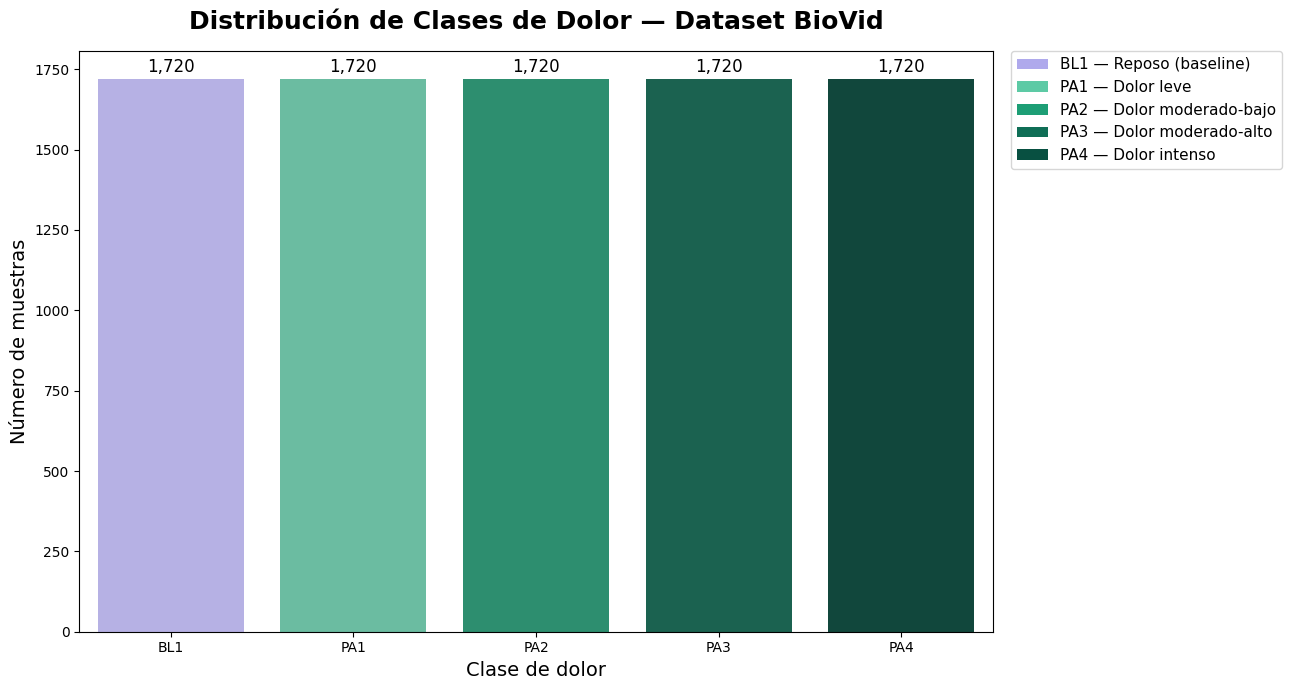

Gráfico guardado como: desbalance_biovid.png


In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import os

# Clases esperadas según el enunciado (BL1 = reposo, PA1-PA4 = estímulos)
ORDEN_CLASES = ['BL1', 'PA1', 'PA2', 'PA3', 'PA4']

# Paleta personalizada: BL1 (reposo) en púrpura, PA1-PA4 en tonos verdes/teal
PALETA = {
    'BL1': '#AFA9EC',
    'PA1': '#5DCAA5',
    'PA2': '#1D9E75',
    'PA3': '#0F6E56',
    'PA4': '#085041',
}
clases_presentes = df_biovid['class_name'].dropna().unique().tolist()
clases_faltantes = [c for c in ORDEN_CLASES if c not in clases_presentes]
if clases_faltantes:
    print(f"⚠ ADVERTENCIA: Clases esperadas no encontradas en el dataset: {clases_faltantes}")


# ─── GRÁFICO DE CLASES DE DOLOR ───────────────────────────────────────────

ORDEN_CLASES = ['BL1', 'PA1', 'PA2', 'PA3', 'PA4']

fig, ax = plt.subplots(figsize=(13, 7))

sns.countplot(
    data=df_biovid,
    x='class_name',
    order=ORDEN_CLASES,
    palette=PALETA,
    edgecolor='none',
    ax=ax
)

ax.set_title(
    'Distribución de Clases de Dolor — Dataset BioVid',
    fontsize=18, fontweight='bold', pad=16
)
ax.set_xlabel('Clase de dolor', fontsize=14)
ax.set_ylabel('Número de muestras', fontsize=14)

for patch in ax.patches:
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height() + 10,
        f'{int(patch.get_height()):,}',
        ha='center', va='bottom', fontsize=12
    )
# Leyenda manual
from matplotlib.patches import Patch
leyenda = [
    Patch(facecolor= PALETA['BL1'], label='BL1 — Reposo (baseline)'),
    Patch(facecolor= PALETA['PA1'], label='PA1 — Dolor leve'),
    Patch(facecolor= PALETA['PA2'], label='PA2 — Dolor moderado-bajo'),
    Patch(facecolor= PALETA['PA3'], label='PA3 — Dolor moderado-alto'),
    Patch(facecolor= PALETA['PA4'], label='PA4 — Dolor intenso'),
]
# Colocar la leyenda fuera del eje para que no tape barras; reservar margen derecho
ax.legend(handles=leyenda, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=11, borderaxespad=0.0)
fig.subplots_adjust(right=0.75)
plt.tight_layout()
# Guardar en gráfico
RUTA_SALIDA ='desbalance_biovid.png'
plt.savefig(RUTA_SALIDA, dpi=150, bbox_inches='tight')

## Mostrar gráfico
plt.show()
print(f"Gráfico guardado como: {RUTA_SALIDA}")



tarea 4


Gráfico guardado como: histograma_edades_biovid.png


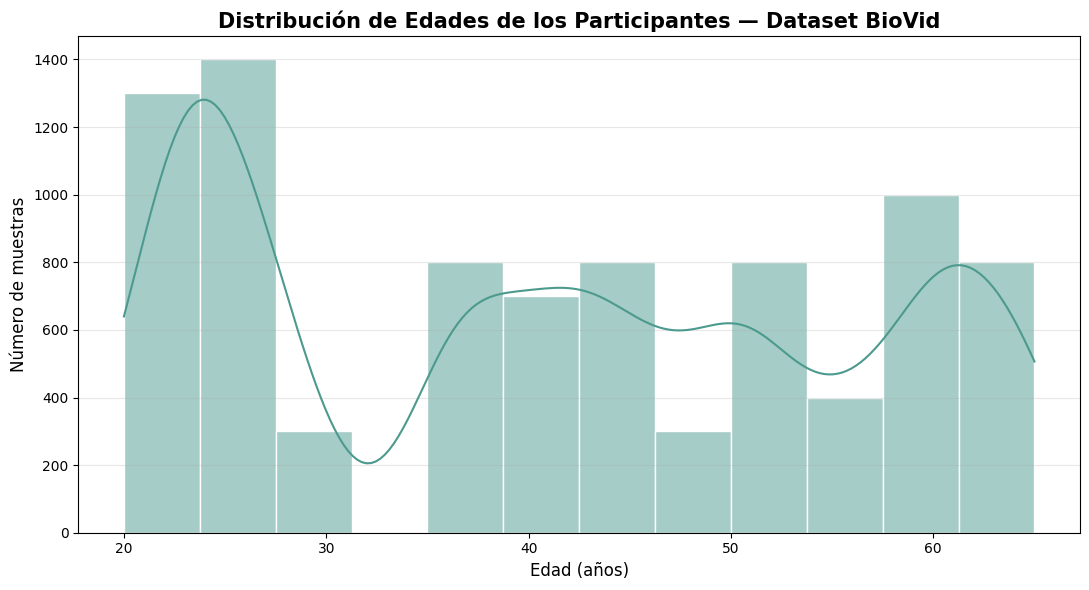

In [ ]:
# Tarea 4: Histograma de distribución de edades
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11, 6))

# Histograma con 12 contenedores y curva de densidad (KDE)
sns.histplot(
    data=df_biovid,
    x='edad',
    bins=12,
    kde=True,
    color='#4C9A8E',
    edgecolor='white'
)

# Títulos y etiquetas
plt.title('Distribución de Edades de los Participantes — Dataset BioVid',
          fontsize=15, fontweight='bold')
plt.xlabel('Edad (años)', fontsize=12)
plt.ylabel('Número de muestras', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Guardar la imagen para el informe
plt.savefig('histograma_edades_biovid.png', dpi=150, bbox_inches='tight')
print("Gráfico guardado como: histograma_edades_biovid.png")

plt.show()

tarea 5

In [ ]:
# Tarea 5: Análisis estadístico
import numpy as np

# --- 1) Distribución porcentual de las clases de dolor ---
orden_clases = ['BL1', 'PA1', 'PA2', 'PA3', 'PA4']
porcentajes = (df_biovid['class_name'].value_counts(normalize=True) * 100).reindex(orden_clases)

print("Distribución porcentual por clase de dolor")
print("-" * 40)
for clase, pct in porcentajes.items():
    print(f"  {clase}: {pct:.2f}%  ({df_biovid['class_name'].value_counts()[clase]} muestras)")

spread = porcentajes.max() - porcentajes.min()
balanceadas = spread < 1.0   # umbral: < 1 punto porcentual de diferencia
print(f"\nDiferencia máx-mín entre clases: {spread:.2f} pts porcentuales")
print(f"¿Clases perfectamente balanceadas? {'SÍ' if balanceadas else 'NO'}")

# --- 2) Análisis demográfico (edad) ---
edad = df_biovid['edad']
print("\nEstadísticos de edad (a nivel de muestra)")
print("-" * 40)
print(edad.describe().round(1))

# Localizar el pico usando los MISMOS bins del histograma (bins=12)
conteos, bordes = np.histogram(edad, bins=12)
i = conteos.argmax()
rango_pico = f"{bordes[i]:.0f}–{bordes[i+1]:.0f}"
pct_pico = conteos[i] / conteos.sum() * 100
print(f"\nRango con mayor acumulación de datos: {rango_pico} años")
print(f"Ese rango concentra el {pct_pico:.1f}% de las muestras")

Distribución porcentual por clase de dolor
----------------------------------------
  BL1: 20.00%  (1720 muestras)
  PA1: 20.00%  (1720 muestras)
  PA2: 20.00%  (1720 muestras)
  PA3: 20.00%  (1720 muestras)
  PA4: 20.00%  (1720 muestras)

Diferencia máx-mín entre clases: 0.00 pts porcentuales
¿Clases perfectamente balanceadas? SÍ

Estadísticos de edad (a nivel de muestra)
----------------------------------------
count    8600.0
mean       41.1
std        14.6
min        20.0
25%        26.0
50%        41.0
75%        54.0
max        65.0
Name: edad, dtype: float64

Rango con mayor acumulación de datos: 24–28 años
Ese rango concentra el 16.3% de las muestras
